# Project 06 - Hierarchical Clustering

In [ ]:
from typing import List, Tuple, Dict
from io import StringIO
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from Bio import Phylo
import numpy as np

sys.path.insert(0, str(Path.cwd() / "distance_matrix_tools"))
from matrix_building import *
from scoring_manual_smith_waterman import smith_waterman

import textdistance as td 
import string

## Building the initial D matrix

`build_distance_matrix` creates the distance matrix D by filling in the pairwise distance scores for each pair of sequences i,j. The scoring function `score_distance` (imported from `distance_matrix_tools/matrix_building`) is a dispatcher that returns the pairwise distance score for two sequences using the appropriate function for a desired `scoring_model`. We use `hamming` distance by default, as the target input data contains sequences of equal length.

Note: the `sequence_type` parameter, with default `AA`, is only used for the `jukes_cantor` scoring method.

In [2]:
# builds D matrix by pulling helpers to compute pairwise scores 
def build_distance_matrix(sequences: Dict[str, str], scoring_model: str = "hamming", sequence_type: str = "AA")\
     -> Tuple[np.ndarray, List[str]]:
    
    ids = list(sequences.keys())
    n = len(ids)
    D = np.zeros((n, n), dtype=float) # make square n x n empty D matrix

    for i, id1 in enumerate(ids):
        for j in range(i + 1, n):
            id2 = ids[j]
            dist = score_distance(sequences[id1], sequences[id2], scoring_model, sequence_type)
            D[i, j] = D[j, i] = dist # mirrors value
    return D, ids

## Creating the class TreeNode
The class `TreeNode` represents a (sub)tree whose root is at a given node; a clade. With n taxa to incorporate, we will initialize n 1-node subtrees. Every time pairs of taxa are agglomerated into a new internal node, a `TreeNode` object for that new internal node is created which contains the `TreeNode` objects for its two children in the `children` attribute (and if it has grandchildren, those child objects will contain those, and so on). Each `TreeNode` also has an attribute `edge_weights` which stores its distance from its direct descendants. 

With this method, and using some heuristic/arbitrary root placement method to join the final two internal nodes (as NJ produces unrooted tree; this root can be entirely removed from the final output depending on Newick string convention), we can incorporate all distance information returned by the NJ algorithm within a single `TreeNode` representing the descendents of that final root. The `walk` method uses recursion to return a Newick string representing the clade stored within the `TreeNode` object.

In [ ]:

class TreeNode:
    """
    Represents a node in a phylogenetic tree.
    Each node can have
    - children: list of child TreeNode objects
    - edge_weights: branch lengths to each child
    - id: node label

    The class has methods to:
    - add children (.add_children)
    - recursively traverse the tree to return a Newick string (.walk)
    """
    def __init__(self, children=None, edge_weights=None, id=None):
        """
        Initializes a new TreeNode object.
        :param children: list of child TreeNode objects
        :param edge_weights: list of branch lengths to each child
        :param id: node label
        """
        self.id = id
        self.edge_weights = edge_weights
        self.children = children

    def add_children(self, children, edge_weights):
        """
        Adds child nodes with their corresponding edge weights
        :param children: list of child TreeNode objects
        :param edge_weights: list of branch lengths to each child
        """
        self.children.extend(children)
        self.edge_weights.extend(edge_weights)

    def walk(self):
        """
        Recursively traverses the tree to make a Newick string
        :return: if at a leaf: self.id. if at an internal node: a Newick-formatted subtree string rooted in the current node.
        """
        #### base case: if leaf node, return its name
        if not self.children:
            return str(self.id)
        
        #### if internal node, build the entire subtree with itself as the root
        child_strings = []

        for child, weight in zip(self.children, self.edge_weights):
            child_strings.append(f"{child.walk()}:{weight}")

        return f"({','.join(child_strings)})" 
        # we currently have no system to assign ids to internal nodes but if we did we could do
        # return f"({','.join(child_strings)}){'' if self.id is None else self.id}"

## Neighbour joining algorithm
At initiation:
- The fasta file in `path` is used to build a `Dict[str, str]` using `fasta_to_Dict` (imported from `distance_matrix_tools/matrix_building`)
- The distance matrix D is built using whichever scoring method is specified (`hamming` by default).
- The list of active nodes (`active_layer`) is created. If `taxon_names` is provided and contains at least as many labels as there are sequences, those labels are used in FASTA order; otherwise, the FASTA headers are used.

Iteration happens while the length of `active_layer` > 2: (so there will be `len(active_layer) - 3` iterations):
- Based on the current D matrix, a Q matrix is calculated
- The pair of taxa i,j with the minimum distance in Q is identified as the next pair to join as siblings 

(this is the canonical NJ method; there are many search strategies to reduce time and space complexity)
- To define the new internal node k, parent of i and j, we compute:
    - k's distance from i and j using the difference of divergence of i and j, and enforcing the addition property of equality
    - k's distance from all remaining nodes, using the average distance of i and j as a clade to all active nodes (note that here, "k"'s distance to i and j becomes 0)
- The distance matrix D is updated with k added and i,j removed
- The active nodes list is updated with `TreeNode` with root k added and `TreeNode`s with root i and j removed

When `active_layer` = 2 is achieved, only two `TreeNode`s remain in the active nodes list. We unite them as siblings in a `TreeNode` object, arbitrarily placing the root midway between the final two surviving clusters.

In [ ]:
def neighbour_joining(scoring_model="hamming", path="data/lafayette_SARS_RT.fasta", taxon_names=None):
    """
    Construct a phylogenetic tree using NJ algorithm.
    :param scoring_model: distance metric used to compute distances between sequences
    :param path: the path to the FASTA file
    :param taxon_names: list of names for the sequences, in FASTA order. If None or not enough names, uses FASTA headers. If too many names, ignores extras.
    :return: the phylogenetic tree object through Phylo.read()
    """
    # Load sequences from fasta
    fasta_file = fasta_to_Dict(path)

    # Build pairwise distance matrix
    D, headers = build_distance_matrix(fasta_file, scoring_model=scoring_model)

    if taxon_names is not None and len(taxon_names) >= len(headers):
        # name them something easier to compare than fasta headers 
        taxon_ids = taxon_names[:len(headers)] # ensures number 
    else: 
        taxon_ids = headers

    # Initialize active nodes; originally all taxa with no edge_weights nor children 
    active_layer = [TreeNode(id=taxon_id) for taxon_id in taxon_ids]


    # This is the main neighbour joining loop
    while len(active_layer) > 2:
        # Compute the Q matrix
        Q = D_to_Q(D)
        # Find the pair with the smallest Q value
        i,j = np.unravel_index(np.argmin(Q), Q.shape)

        # Compute row sums in D
        r_i = D[i,:].sum()                                  # divergence of i = row sums at i
        r_j = D[j,:].sum()                                  # divergence of j = row sums at j

        # Retrieve sibling distance from D
        d_ij = D[i,j]                                       # distance of i to j 

        # Compute branch lengths to k
        d_ik = (d_ij + (r_i - r_j) / (D.shape[0]-2))/2      # distance of k to i
        d_jk = d_ij - d_ik                                  # distance of k to j

        # Distance from k to all the other nodes
        # k will represent "i and j" in the distance matrix
        D_kx = (D[i,:] + D[j,:] - d_ij)/2                   # vector of distances from "i and j" to every active node
        # there should be two zeroes in D_kx where x = i or x = j

        # Add new node k's distances to matrix
        D = np.vstack([D, D_kx])                            # add D_kx to D as the final row
        D_kx = np.concatenate([D_kx,[0]])
        D = np.hstack([D, D_kx.reshape(-1,1)])              # add D_kx with appended 0 to D as the final column

        # Remove merged nodes i,j from D
        D = np.delete(D, [i,j], 0)
        D = np.delete(D, [i,j], 1)

        # Remove merged nodes from active nodes list
        node_i = active_layer[i]
        node_j = active_layer[j]
        for idx in sorted([i, j], reverse=True): # pop the larger index first
            active_layer.pop(idx)

        # create TreeNode with root = k in active nodes list
        active_layer.append(TreeNode(children=[node_i, node_j], edge_weights=[d_ik, d_jk]))
    

    # Final root node combining last two clusters
    # arbitrary 
    final_dist = D[0, 1]/2
    root = TreeNode(children=[active_layer[0], active_layer[1]], edge_weights=[final_dist, final_dist])

    # Convert to newick
    newick_string = root.walk()
    x = newick_string + ";"
    # the ";" denotes that the tree is complete, which is important in multi-tree newick strings, though irrelevant here

    # Create tree object using Phylo.read
    tree = Phylo.read(StringIO(x), "newick")
    return tree

## Drawing trees
We compare trees drawn using matrices of distance scores computed using 2 common scoring schemes.  
- p-distance between two strings is their Hamming distance normalized by their length (the Hamming distance being the sum of equivalent positions for two equal-length strings)
- Damerau–Levenshtein distance between two strings is the minimum number of insertions, deletions, single-character substitutions, and transpositions of adjacent single characters to get from one string to the other. 

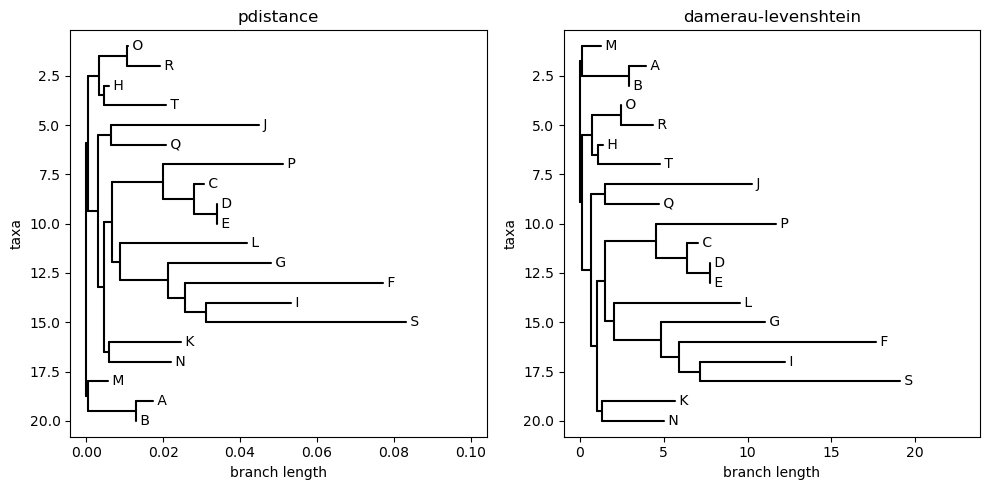

In [5]:
scoring_models = [
     "pdistance",
     "damerau-levenshtein"
]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes = axes.flatten()
alphabet_list = list(string.ascii_uppercase)

for ax, model in zip(axes, scoring_models):
    tree = neighbour_joining(model, taxon_names=alphabet_list)  # assumes it returns a tree object
    Phylo.draw(
        tree, 
        axes = ax, 
        do_show = False,
        # branch_labels = lambda clade: (
        #     None if clade.branch_length is None else f"{clade.branch_length:.2f}"
        #     ) # mostly for debugging; without working on the more this is kind of messy
        )
    
    ax.set_title(model)

plt.tight_layout()
plt.show()

## Using Smith-Waterman local alignment scores
Smith-Waterman scores are local alignment scores which do not map in an obvious way to distance scores. We can convert it into a measure of dissimilarity to force these scores into a distance matrix framework. In the function defined below, we normalize pairwise scores by the smaller of the two self-alignment scores (with our default scoring scheme where match=1, self-alignment scores equal the sequence length) and define dissimilarity as one minus this normalized score (which is in [0,1]). The idea is that stronger local similarity implies smaller dissimilarity, but note that because Smith–Waterman scores are concerned only with the highest-scoring local region, two sequences can appear artificially close if they share a short conserved motif despite being otherwise divergent.

In [ ]:
# smith_waterman(seq1, seq2, match=1, mismatch=-1, gap=-1, score_only=True) returns the max local alignment score for a pair of sequences
def smith_waterman_dissimilarity(seq1, seq2):
    return 1 - (smith_waterman(seq1, seq2) / min(smith_waterman(seq1, seq1), smith_waterman(seq2, seq2)))

Regardless, building a NJ tree for our 20 sequences with this heuristic transformation yields a result that is comparable to what we saw before, with some agreements (eg. K and N are each other's closest relatives) and disagreements (eg. K and N are in an outgroup w.r.t. all other taxa). 

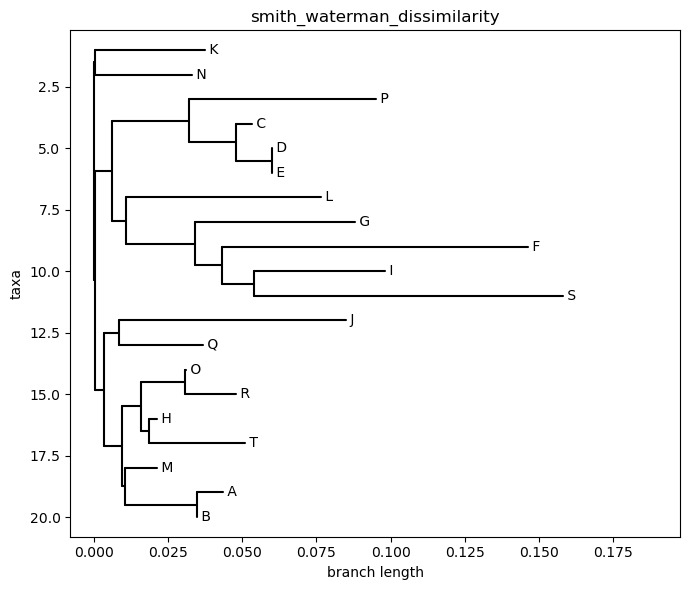

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
tree_sw = neighbour_joining(scoring_model=smith_waterman_dissimilarity,path="data/lafayette_SARS_RT.fasta",taxon_names=alphabet_list)
Phylo.draw(tree_sw, axes=ax, do_show=False)
ax.set_title("smith_waterman_dissimilarity")
plt.tight_layout()
plt.show()